## **EDA Flows**

In this file we will load data from the database in order to analyze it.

**Datasbase connection**

In [1]:
import sqlite3
import pandas as pd

# Ruta a tu base de datos
db_path = r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\data\thesis_database.db"

# Conexión
conn = sqlite3.connect(db_path)

print("Connected!")

Connected!


**Load data**

In [2]:
df_regions = pd.read_sql("SELECT * FROM Regions", conn)
df_regions.head()

,region_id,region_name
0,1,Baltic
1,2,CWE
2,3,Nordic


In [5]:
df_bidding_zones = pd.read_sql("SELECT * FROM BiddingZones", conn)
df_bidding_zones.head()

,zone_id,zone_code,country,region_id
0,1,EE,Estonia,1
1,2,LT,Lithuania,1
2,3,LV,Latvia,1
3,4,AT,Austria,2
4,5,BE,Belgium,2


In [6]:
df_prices = pd.read_sql("SELECT * FROM flows", conn)
df_prices.head()

,flow_id,from_zone_id,to_zone_id,delivery_day,hour,flow_value
0,1,8,13,2020-01-01,0,0.0
1,2,9,13,2020-01-01,0,0.0
2,3,11,15,2020-01-01,0,0.0
3,4,12,13,2020-01-01,0,0.0
4,5,12,14,2020-01-01,0,200.0


In [7]:
df_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230470 entries, 0 to 230469
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   flow_id       230470 non-null  int64  
 1   from_zone_id  230470 non-null  int64  
 2   to_zone_id    230470 non-null  int64  
 3   delivery_day  230470 non-null  object 
 4   hour          230470 non-null  int64  
 5   flow_value    230470 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 10.6+ MB


## **1. Basic information about the data**

In [8]:
df_prices.columns

Index(['flow_id', 'from_zone_id', 'to_zone_id', 'delivery_day', 'hour',
       'flow_value'],
      dtype='object')

In [10]:
import sqlite3
import pandas as pd
import numpy as np
from pathlib import Path

# =========================
# PATH TO DB
# =========================
project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool")
db_path = project_root / "data" / "thesis_database.db"

# =========================
# CONNECT DB
# =========================
conn = sqlite3.connect(db_path)

# =========================
# LOAD TABLES
# =========================
df_flows = pd.read_sql_query("""
    SELECT flow_id, from_zone_id, to_zone_id, delivery_day, hour, flow_value
    FROM Flows
""", conn)

df_prices = pd.read_sql_query("""
    SELECT price_id, zone_id, delivery_day, hour, price_value
    FROM Prices
""", conn)

df_zones = pd.read_sql_query("""
    SELECT zone_id, zone_code, country, region_id
    FROM BiddingZones
""", conn)

conn.close()

# =========================
# CLEAN TYPES
# =========================
df_flows["delivery_day"] = pd.to_datetime(df_flows["delivery_day"])
df_prices["delivery_day"] = pd.to_datetime(df_prices["delivery_day"])

df_flows["hour"] = pd.to_numeric(df_flows["hour"], errors="coerce")
df_prices["hour"] = pd.to_numeric(df_prices["hour"], errors="coerce")

df_flows["flow_value"] = pd.to_numeric(df_flows["flow_value"], errors="coerce")
df_prices["price_value"] = pd.to_numeric(df_prices["price_value"], errors="coerce")

df_flows = df_flows.dropna(subset=["from_zone_id", "to_zone_id", "delivery_day", "hour", "flow_value"]).copy()
df_prices = df_prices.dropna(subset=["zone_id", "delivery_day", "hour", "price_value"]).copy()

df_flows["hour"] = df_flows["hour"].astype(int)
df_prices["hour"] = df_prices["hour"].astype(int)

df_flows["from_zone_id"] = df_flows["from_zone_id"].astype(int)
df_flows["to_zone_id"] = df_flows["to_zone_id"].astype(int)
df_prices["zone_id"] = df_prices["zone_id"].astype(int)

# =========================
# REMOVE POSSIBLE DUPLICATES
# =========================
df_flows = df_flows.drop_duplicates(
    subset=["from_zone_id", "to_zone_id", "delivery_day", "hour"],
    keep="first"
).copy()

# =========================
# PREPARE PRICES FOR MERGE
# =========================
df_prices_from = df_prices.rename(columns={
    "zone_id": "from_zone_id",
    "price_value": "price_from"
})[["from_zone_id", "delivery_day", "hour", "price_from"]]

df_prices_to = df_prices.rename(columns={
    "zone_id": "to_zone_id",
    "price_value": "price_to"
})[["to_zone_id", "delivery_day", "hour", "price_to"]]

# =========================
# MERGE FLOWS WITH PRICES
# =========================
df_flow_prices = df_flows.merge(
    df_prices_from,
    on=["from_zone_id", "delivery_day", "hour"],
    how="left"
)

df_flow_prices = df_flow_prices.merge(
    df_prices_to,
    on=["to_zone_id", "delivery_day", "hour"],
    how="left"
)

# =========================
# REMOVE ROWS WITHOUT MATCHING PRICES
# =========================
df_flow_prices = df_flow_prices.dropna(
    subset=["price_from", "price_to", "flow_value"]
).copy()

# =========================
# CALCULATE SPREAD METRICS
# =========================
df_flow_prices["price_spread"] = df_flow_prices["price_to"] - df_flow_prices["price_from"]
df_flow_prices["abs_price_spread"] = df_flow_prices["price_spread"].abs()
df_flow_prices["abs_flow_value"] = df_flow_prices["flow_value"].abs()
df_flow_prices["spread_x_flow"] = df_flow_prices["abs_price_spread"] * df_flow_prices["abs_flow_value"]

# =========================
# CREATE BIDIRECTIONAL INTERCONNECTION
# zone_a = lower id
# zone_b = higher id
# =========================
df_flow_prices["zone_a_id"] = df_flow_prices[["from_zone_id", "to_zone_id"]].min(axis=1)
df_flow_prices["zone_b_id"] = df_flow_prices[["from_zone_id", "to_zone_id"]].max(axis=1)

# =========================
# AGGREGATE BY INTERCONNECTION
# =========================
interconnection_metrics = df_flow_prices.groupby(
    ["zone_a_id", "zone_b_id"],
    as_index=False
).agg(
    observations=("flow_id", "count"),
    mean_abs_spread=("abs_price_spread", "mean"),
    median_abs_spread=("abs_price_spread", "median"),
    max_abs_spread=("abs_price_spread", "max"),
    mean_signed_spread=("price_spread", "mean"),
    mean_flow=("flow_value", "mean"),
    median_flow=("flow_value", "median"),
    total_abs_flow=("abs_flow_value", "sum"),
    total_spread_x_flow=("spread_x_flow", "sum")
)

interconnection_metrics["weighted_abs_spread"] = (
    interconnection_metrics["total_spread_x_flow"] / interconnection_metrics["total_abs_flow"]
)

# =========================
# ADD ZONE CODES
# =========================
zones_a = df_zones.rename(columns={
    "zone_id": "zone_a_id",
    "zone_code": "zone_a_code"
})[["zone_a_id", "zone_a_code"]]

zones_b = df_zones.rename(columns={
    "zone_id": "zone_b_id",
    "zone_code": "zone_b_code"
})[["zone_b_id", "zone_b_code"]]

interconnection_metrics = interconnection_metrics.merge(
    zones_a,
    on="zone_a_id",
    how="left"
)

interconnection_metrics = interconnection_metrics.merge(
    zones_b,
    on="zone_b_id",
    how="left"
)

interconnection_metrics["interconnection_name"] = (
    interconnection_metrics["zone_a_code"] + " - " + interconnection_metrics["zone_b_code"]
)

# =========================
# REORDER COLUMNS
# =========================
interconnection_metrics = interconnection_metrics[
    [
        "zone_a_id", "zone_b_id",
        "zone_a_code", "zone_b_code", "interconnection_name",
        "observations",
        "mean_abs_spread", "median_abs_spread", "max_abs_spread",
        "mean_signed_spread",
        "mean_flow", "median_flow",
        "total_abs_flow", "weighted_abs_spread"
    ]
].copy()

# =========================
# OPTIONAL FILTER
# avoid tiny / irrelevant interconnections
# =========================
interconnection_metrics_filtered = interconnection_metrics[
    (interconnection_metrics["observations"] >= 100) &
    (interconnection_metrics["total_abs_flow"] > 0)
].copy()

# =========================
# MOST EXPENSIVE INTERCONNECTIONS
# =========================
most_expensive_interconnections = interconnection_metrics_filtered.sort_values(
    "weighted_abs_spread",
    ascending=False
).reset_index(drop=True)

print("\nMOST EXPENSIVE INTERCONNECTIONS")
print(
    most_expensive_interconnections[
        [
            "interconnection_name",
            "weighted_abs_spread",
            "median_abs_spread",
            "max_abs_spread",
            "total_abs_flow",
            "observations"
        ]
    ].head(10)
)

# =========================
# CHEAPEST INTERCONNECTIONS
# =========================
cheapest_interconnections = interconnection_metrics_filtered.sort_values(
    "weighted_abs_spread",
    ascending=True
).reset_index(drop=True)

print("\nCHEAPEST INTERCONNECTIONS")
print(
    cheapest_interconnections[
        [
            "interconnection_name",
            "weighted_abs_spread",
            "median_abs_spread",
            "max_abs_spread",
            "total_abs_flow",
            "observations"
        ]
    ].head(10)
)

# =========================
# FULL FINAL TABLE
# =========================
interconnection_metrics_final = interconnection_metrics_filtered.sort_values(
    "weighted_abs_spread",
    ascending=False
).reset_index(drop=True)

print("\nFULL METRICS TABLE")
print(interconnection_metrics_final.head(20))


MOST EXPENSIVE INTERCONNECTIONS
  interconnection_name  weighted_abs_spread  median_abs_spread  \
0             NL - NO2            23.429109             21.945   
1            GER - NO2            23.182482             28.390   
2            DK1 - NO2            18.560013             14.675   
3            NO1 - SE3            12.703560              3.475   
4            NO4 - SE1             7.032430              0.320   
5            NO3 - SE2             5.681050              0.000   
6            NO4 - SE2             5.410234              0.320   
7            NO1 - NO3             2.233174              1.010   
8            NO3 - NO5             1.903606              0.970   
9            NO3 - NO4             0.995794              0.000   

   max_abs_spread  total_abs_flow  observations  
0          192.74       4832761.3         17572  
1          104.45        225035.5          2112  
2          192.74       9090742.4         17572  
3          239.32       9057029.8       

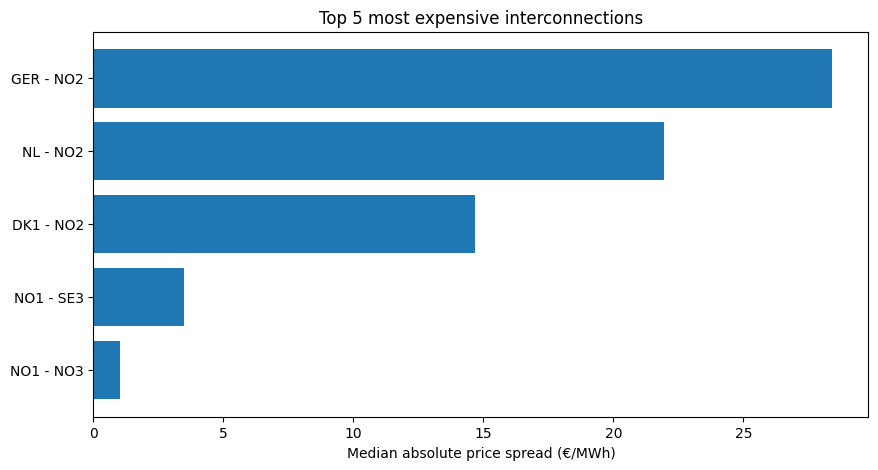

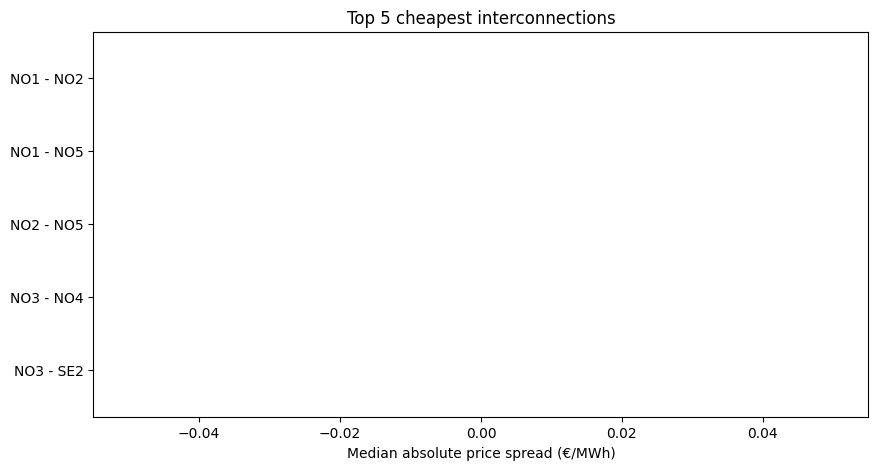

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# TOP 5 MOST EXPENSIVE
top_expensive = (
    interconnection_metrics_final
    .sort_values("median_abs_spread", ascending=False)
    .head(5)
    .sort_values("median_abs_spread", ascending=True)
)

plt.figure(figsize=(10, 5))
plt.barh(top_expensive["interconnection_name"], top_expensive["median_abs_spread"])
plt.xlabel("Median absolute price spread (€/MWh)")
plt.title("Top 5 most expensive interconnections")
plt.show()


# TOP 5 CHEAPEST
top_cheap = (
    interconnection_metrics_final
    .sort_values("median_abs_spread", ascending=True)
    .head(5)
    .sort_values("median_abs_spread", ascending=True)
)

plt.figure(figsize=(10, 5))
plt.barh(top_cheap["interconnection_name"], top_cheap["median_abs_spread"])
plt.xlabel("Median absolute price spread (€/MWh)")
plt.title("Top 5 cheapest interconnections")
plt.show()